In [1]:
# Лабораторна робота 4: Глибокий аналіз і візуалізація даних
# Виконав: Байков Олександр
# Був присутній на парі
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime


In [6]:
# Завантаження датасету
from google.colab import files
uploaded = files.upload()




Saving Museum_Visitors.csv to Museum_Visitors.csv


In [7]:
import pandas as pd

df = pd.read_csv("Museum_Visitors.csv")
df.head()  # показати перші рядки таблиці

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


In [8]:
# Завдання 2 Вивести перші 5 рядків датасету
print("Перші 5 рядків датасету:")
print(df.head())

Перші 5 рядків датасету:
                    Month  America Tropical Interpretive Center  Avila Adobe  \
0  01/01/2014 12:00:00 AM                                  6602        24778   
1  02/01/2014 12:00:00 AM                                  5029        18976   
2  03/01/2014 12:00:00 AM                                  8129        25231   
3  04/01/2014 12:00:00 AM                                  2824        26989   
4  05/01/2014 12:00:00 AM                                 10694        36883   

   Chinese American Museum  Gateway to Nature Center  Firehouse Museum  \
0                     1581                       NaN              4486   
1                     1785                       NaN              4172   
2                     3229                       NaN              7082   
3                     2129                       NaN              6756   
4                     3676                       NaN             10858   

   Hellman Quon  IAMLA  Pico House   Visitor Cent

In [11]:
# Завдання 3
# Розмір датасету
print("\n🔹 Розмір датасету:", df.shape)

# Типи даних
print("\n🔹 Типи даних:")
print(df.dtypes)

# Кількість пропусків
print("\n🔹 Пропущені значення:")
print(df.isnull().sum())


🔹 Розмір датасету: (85, 12)

🔹 Типи даних:
Month                                     object
America Tropical Interpretive Center       int64
Avila Adobe                                int64
Chinese American Museum                    int64
Gateway to Nature Center                 float64
Firehouse Museum                           int64
Hellman Quon                             float64
IAMLA                                    float64
Pico House                               float64
Visitor Center/ El Tranquilo Gallery     float64
Museum of Social Justice                 float64
Biscailuz Gallery/ PK Outdoor Exhibit    float64
dtype: object

🔹 Пропущені значення:
Month                                     0
America Tropical Interpretive Center      0
Avila Adobe                               0
Chinese American Museum                   0
Gateway to Nature Center                 53
Firehouse Museum                          0
Hellman Quon                             59
IAMLA                  

In [12]:
# Завдання 4
# Пошук дублікатів
duplicates = df.duplicated().sum()
print("\n🔹 Кількість дублікатів:", duplicates)



🔹 Кількість дублікатів: 0


In [16]:
# Завдання 5
df['Month'] = pd.to_datetime(df['Month'])
print("Роки:", sorted(df['Month'].dt.year.unique()))

Роки: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


<ipython-input-16-3923f3632564>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'])


In [ ]:
# Додав від себе, мені так зручніше, якщо ви не проти.
df = df.rename(columns={
    'america_tropical_interpretive_center': 'тропічний_інтерпретаційний_центр_америки',
    'avila_adobe': 'авіла_адобе',
    'chinese_american_museum': 'китайсько_американський_музей',
    'gateway_to_nature_center': 'центр_ворота_до_природи',
    'firehouse_museum': 'музей_пожежної_станції',
    'hellman_quon': 'хеллман_квон',
    'iamla': 'музей_латинської_америки',
    'pico_house_': 'піко_хаус',
    'visitor_center__el_tranquilo_gallery': 'візиторський_центр_ел_транкіло',
    'museum_of_social_justice': 'музей_соціальної_справедливості',
    'biscailuz_gallery__pk_outdoor_exhibit': 'галерея_біскайлуз_та_вулична_виставка'
})


In [19]:
# Завдання 6
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("-", "_")
df.columns


Index(['month', 'тропічний_інтерпретаційний_центр_америки', 'авіла_адобе',
       'китайсько_американський_музей', 'центр_ворота_до_природи',
       'музей_пожежної_станції', 'хеллман_квон', 'музей_латинської_америки',
       'піко_хаус', 'візиторський_центр_ел_транкіло',
       'музей_соціальної_справедливості',
       'галерея_біскайлуз_та_вулична_виставка'],
      dtype='object')

In [20]:
# Завдання 7
average_visitors = df.drop(columns='month').mean().sort_values(ascending=False)
print("Середня кількість відвідувачів по музеях:")
print(average_visitors)


Середня кількість відвідувачів по музеях:
авіла_адобе                                 19904.952941
тропічний_інтерпретаційний_центр_америки     5637.694118
музей_пожежної_станції                       5286.776471
візиторський_центр_ел_транкіло               2634.800000
китайсько_американський_музей                2359.117647
музей_соціальної_справедливості              2125.972973
піко_хаус                                    1329.710843
центр_ворота_до_природи                      1247.375000
галерея_біскайлуз_та_вулична_виставка        1088.615385
музей_латинської_америки                      882.611111
хеллман_квон                                  353.461538
dtype: float64


In [21]:
# Завдання 8
df_2018 = df[df['month'].dt.year == 2018]

min_2018 = df_2018.drop(columns='month').min()
max_2018 = df_2018.drop(columns='month').max()

print("\nМінімум у 2018:")
print(min_2018)

print("\nМаксимум у 2018:")
print(max_2018)



Мінімум у 2018:
тропічний_інтерпретаційний_центр_америки     3180.0
авіла_адобе                                 14718.0
китайсько_американський_музей                2078.0
центр_ворота_до_природи                         NaN
музей_пожежної_станції                       3306.0
хеллман_квон                                    NaN
музей_латинської_америки                      965.0
піко_хаус                                     185.0
візиторський_центр_ел_транкіло                  NaN
музей_соціальної_справедливості              2332.0
галерея_біскайлуз_та_вулична_виставка         349.0
dtype: float64

Максимум у 2018:
тропічний_інтерпретаційний_центр_америки     5837.0
авіла_адобе                                 25173.0
китайсько_американський_музей                4960.0
центр_ворота_до_природи                         NaN
музей_пожежної_станції                       8013.0
хеллман_квон                                    NaN
музей_латинської_америки                     1601.0
піко_хаус     

In [22]:
# Завдання 9
import calendar

df_2015 = df[df['month'].dt.year == 2015]
df_2015['total'] = df_2015.drop(columns='month').sum(axis=1)
df_2015['month_name'] = df_2015['month'].dt.month.apply(lambda x: calendar.month_name[x])

max_month = df_2015.loc[df_2015['total'].idxmax(), 'month_name']
min_month = df_2015.loc[df_2015['total'].idxmin(), 'month_name']

print("Найбільше відвідувань:", max_month)
print("Найменше відвідувань:", min_month)


Найбільше відвідувань: May
Найменше відвідувань: February


<ipython-input-22-dcd2d30b8ab2>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015['total'] = df_2015.drop(columns='month').sum(axis=1)
<ipython-input-22-dcd2d30b8ab2>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015['month_name'] = df_2015['month'].dt.month.apply(lambda x: calendar.month_name[x])


In [24]:
# Завдання 10
summer = [6, 7, 8]
winter = [12, 1, 2]

avila_2018 = df_2018[['month', 'авіла_адобе']].copy()
avila_2018['month_num'] = avila_2018['month'].dt.month

summer_visits = avila_2018[avila_2018['month_num'].isin(summer)]['авіла_адобе'].mean()
winter_visits = avila_2018[avila_2018['month_num'].isin(winter)]['авіла_адобе'].mean()

print("Середня кількість відвідувачів влітку 2018:", summer_visits)
print("Взимку 2018:", winter_visits)



Середня кількість відвідувачів влітку 2018: 22040.666666666668
Взимку 2018: 16235.0


In [26]:
# Завдання 11
df_2016 = df[df['month'].dt.year == 2016].copy()
df_2016['місяць'] = df_2016['month'].dt.month

correlations = df_2016.drop(columns='month').corrwith(df_2016['місяць'])
print("Кореляція з місяцем у 2016:")
print(correlations)


Кореляція з місяцем у 2016:
тропічний_інтерпретаційний_центр_америки   -0.225935
авіла_адобе                                 0.063396
китайсько_американський_музей              -0.412350
центр_ворота_до_природи                          NaN
музей_пожежної_станції                     -0.198522
хеллман_квон                                1.000000
музей_латинської_америки                   -0.552948
піко_хаус                                   0.554689
візиторський_центр_ел_транкіло             -0.736433
музей_соціальної_справедливості                  NaN
галерея_біскайлуз_та_вулична_виставка      -0.133853
місяць                                      1.000000
dtype: float64


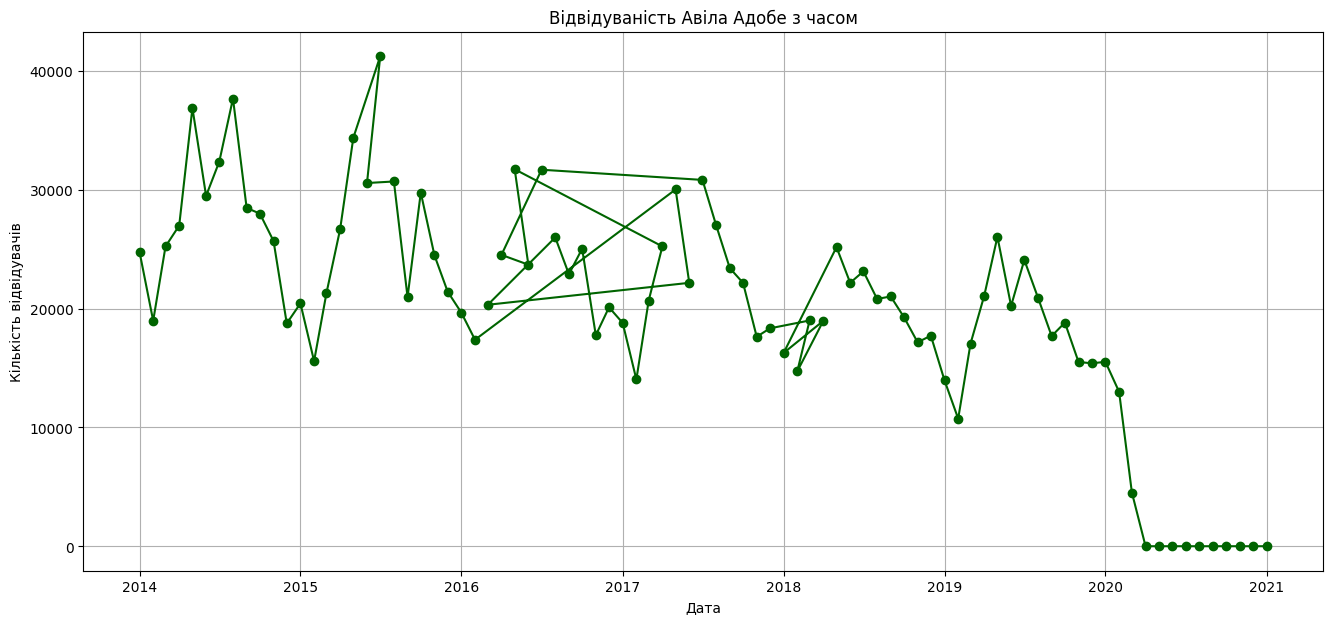

In [30]:
# Завдання 12
plt.figure(figsize=(16, 7))
plt.plot(df['month'], df['авіла_адобе'], color='darkgreen', marker='o')
plt.title("Відвідуваність Авіла Адобе з часом")
plt.xlabel("Дата")
plt.ylabel("Кількість відвідувачів")
plt.grid()
plt.show()



<ipython-input-35-2e26edfba4d9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='рік', y='китайсько_американський_музей', palette='viridis')


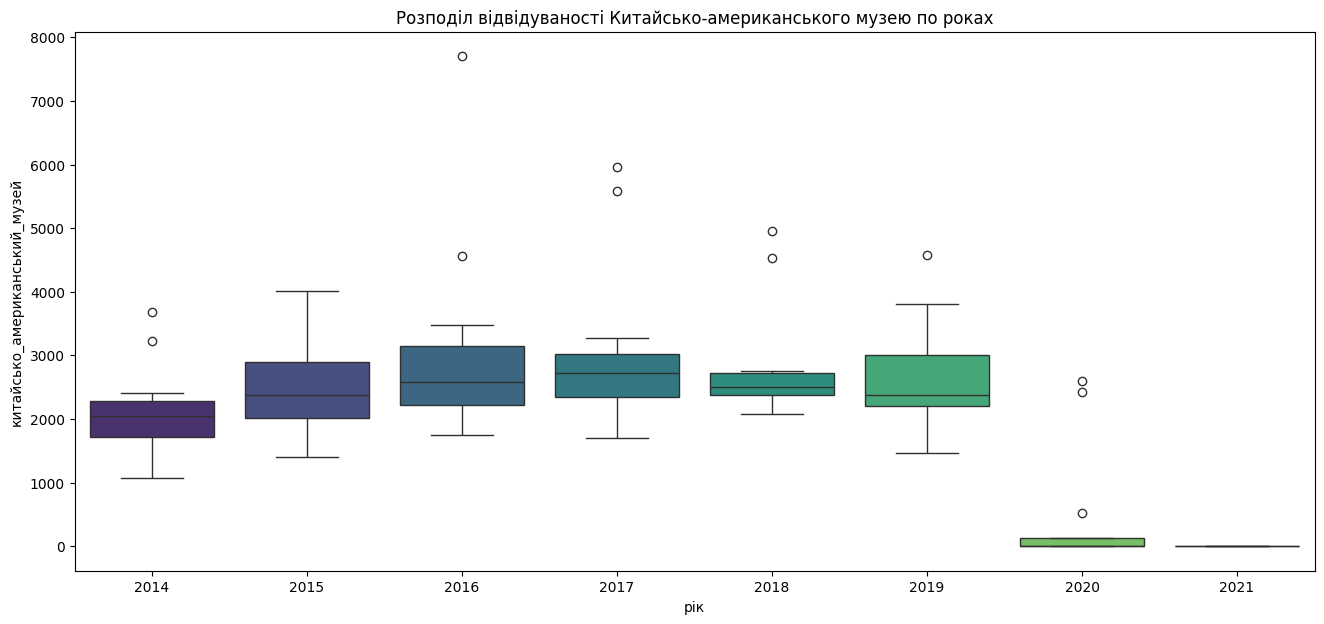

In [35]:
# Завдання 13
df['рік'] = df['month'].dt.year
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='рік', y='китайсько_американський_музей', palette='viridis')
plt.title("Розподіл відвідуваності Китайсько-американського музею по роках")
plt.show()



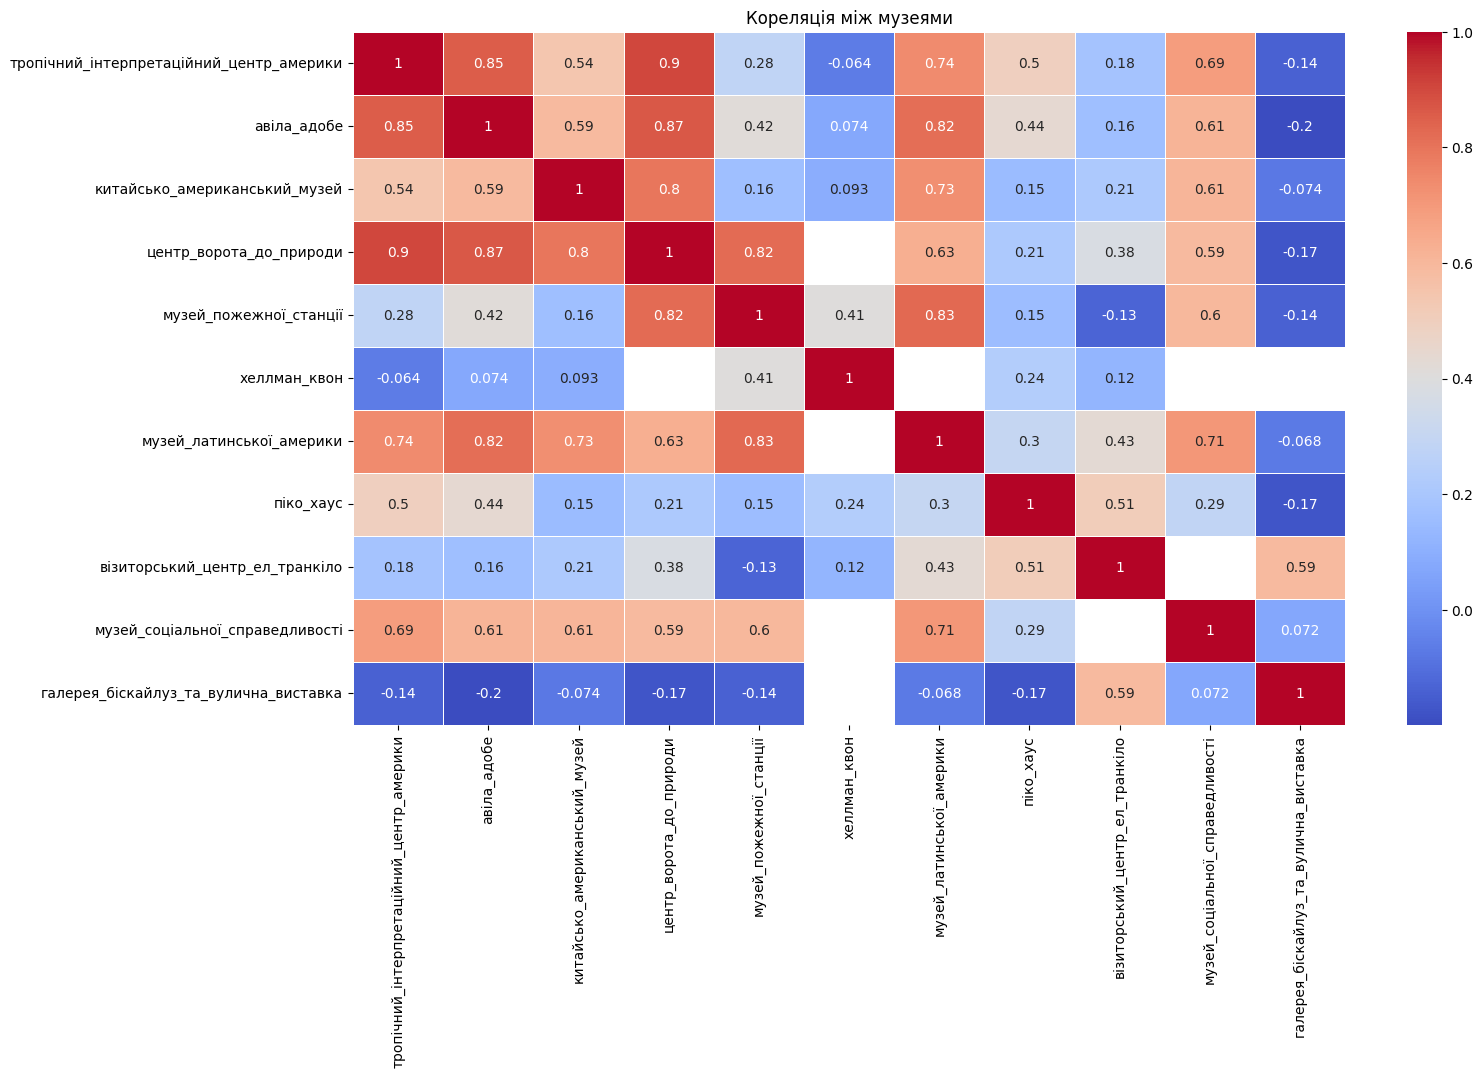

In [37]:
# Завдання 14
corr = df.drop(columns=['month', 'рік']).corr()
plt.figure(figsize=(16, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white')
plt.title("Кореляція між музеями")
plt.show()


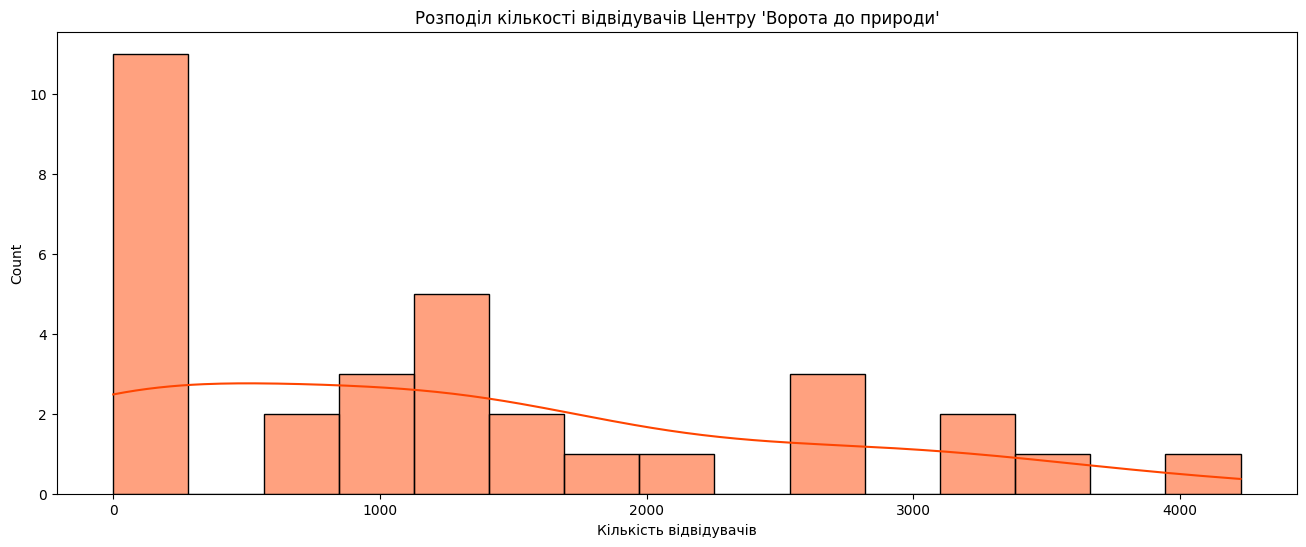

In [38]:
# Завдання 15
plt.figure(figsize=(16, 6))
sns.histplot(df['центр_ворота_до_природи'].dropna(), bins=15, kde=True, color='orangered')
plt.title("Розподіл кількості відвідувачів Центру 'Ворота до природи'")
plt.xlabel("Кількість відвідувачів")
plt.show()


<ipython-input-39-521b7cc24f90>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_visitors.values, y=average_visitors.index, palette=colors)


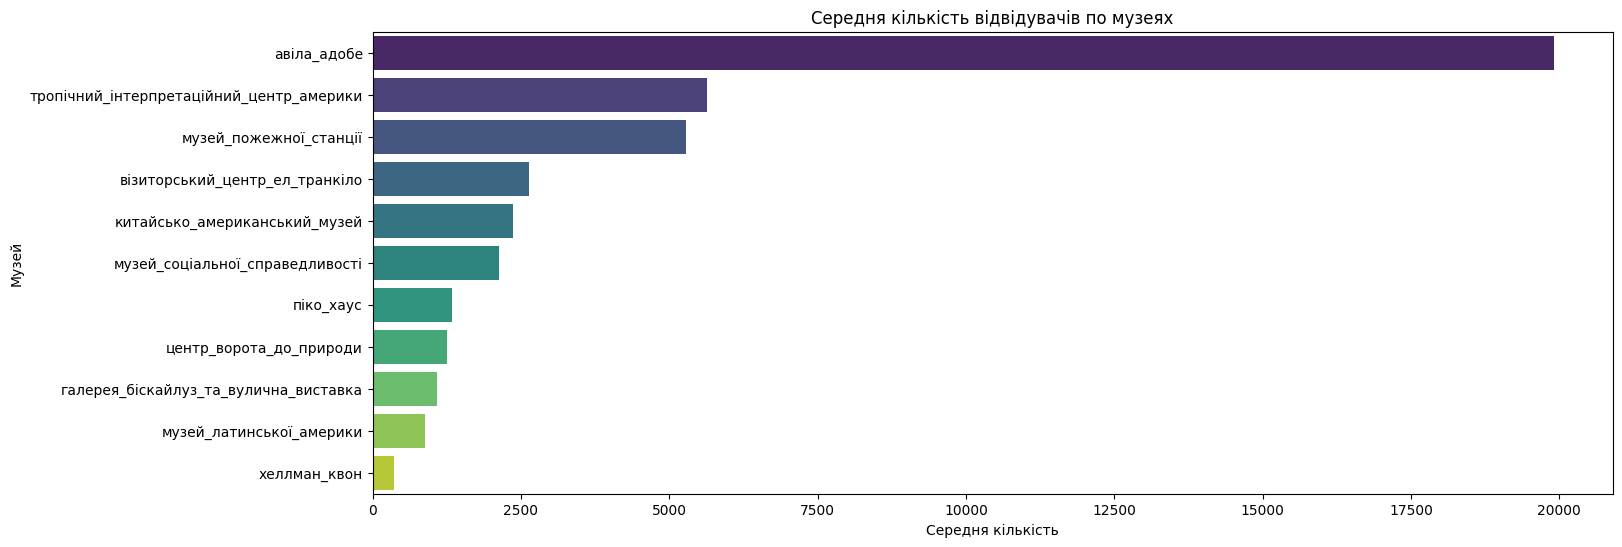

In [39]:
# Завдання 16
plt.figure(figsize=(16, 6))
colors = sns.color_palette("viridis", len(average_visitors))
sns.barplot(x=average_visitors.values, y=average_visitors.index, palette=colors)
plt.title("Середня кількість відвідувачів по музеях")
plt.xlabel("Середня кількість")
plt.ylabel("Музей")
plt.show()


In [ ]:
# Висновки

# У результаті аналізу було досліджено відвідуваність 11 музеїв у період з 2014 по 2021 рік.

# Найпопулярнішим музеєм є **Авіла Адобе**, який має найвищу середню відвідуваність за всі роки.

#Найменша загальна кількість відвідувань у 2015 році була у **лютому**, а найбільша — у **травні**. Це може свідчити про вплив сезонності на музейну відвідуваність.

#У 2018 році музеї загалом мали більше відвідувачів у **літні місяці** порівняно із зимовими, зокрема для **Авіла Адобе**. Це підтверджує тренд сезонності.

#Кореляційний аналіз показав зв’язок між деякими музеями, наприклад, **Авіла Адобе** та **Музей пожежної станції** мають схожі тенденції змін відвідуваності, що може вказувати на їхню спільну популярність серед відвідувачів.



